# Vector Error Correction Model (VECM) Parameter Estimation With Two Cointegrating Vectors

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"]   
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.4, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$", r"$\Delta x_3$"])

## VECM(1) Two Cointegrating Vectors

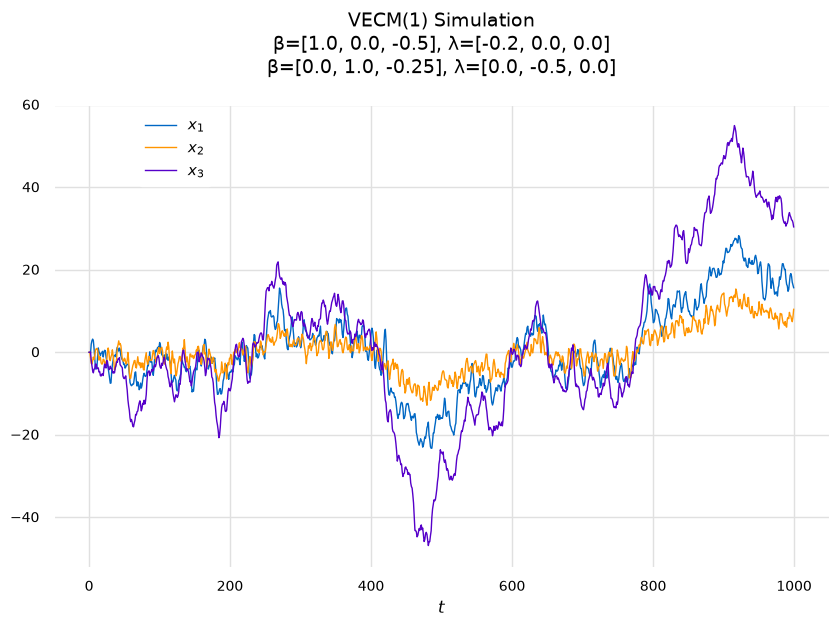

In [3]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [4]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [5]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


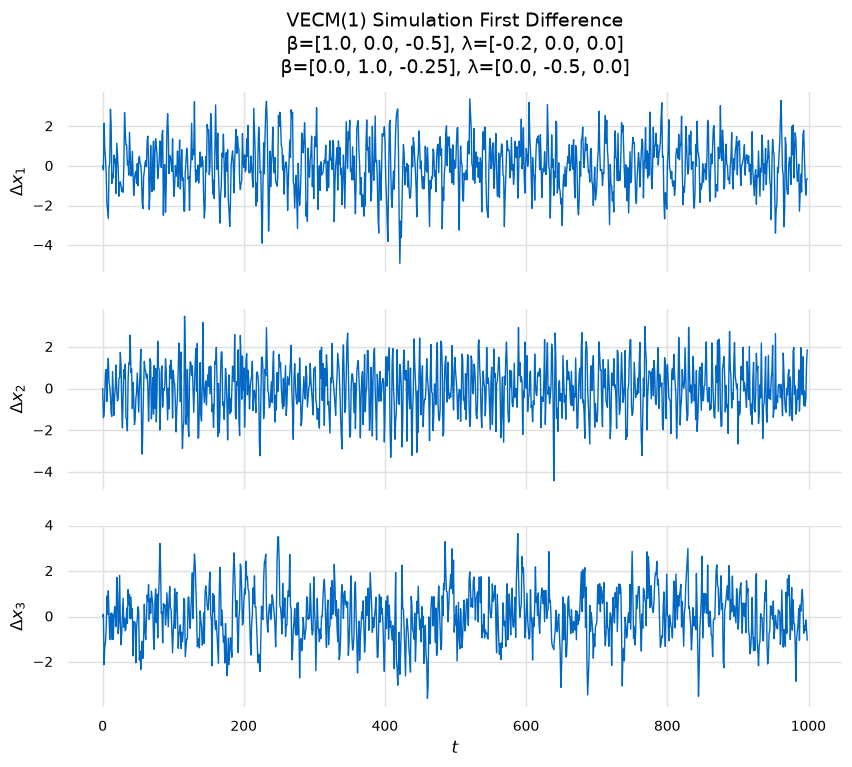

In [6]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Lag Order Determination

In [7]:
result, result_model = vecm.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.8079,0.8818,2.243,0.8360
1,-0.02565*,0.09261*,0.9747*,0.01931*
2,-0.01272,0.1499,0.9874,0.04909
3,0.001484,0.2084,1.001,0.08016
4,0.01277,0.2641,1.013,0.1083


In [8]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
   "_VAROrderTestReport__order": {
      "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
      "order": {
         "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.02564950878423073
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
      "order": {
         "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "884c07db-ff4b-4ea2-83c0-3dd7dbd6742c",
       

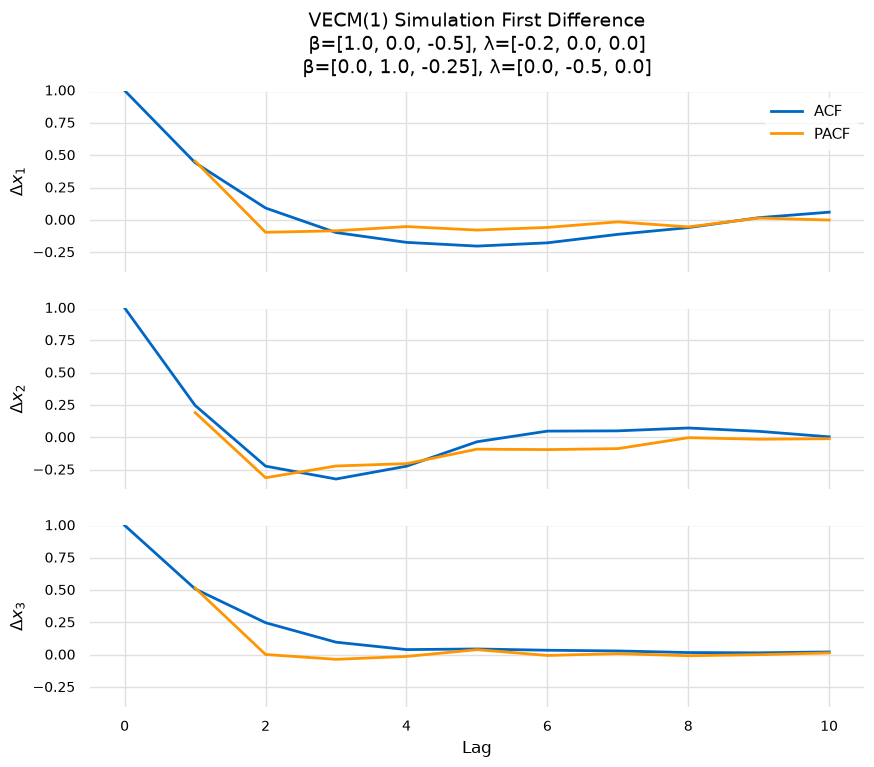

In [9]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [10]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1561.100
Date:                Sun, 30 Aug 2026   AIC                           3128.200
Time:                        17:29:35   BIC                           3142.920
Sample:                             0   HQIC                          3133.795
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0152      0.066      0.232      0.817      -0.113       0.144
ar.L1          0.4420      0.029     15.192      0.000       0.385       0.499
sigma2         1.3327      0.061     21.975      0.000       1.214       1.452
===================================================================================
Ljung-Box (L1) (Q):                   3.28   Jarque-Bera (JB):                 0.67
Prob(Q):                              0.07   Prob(JB):                         0.71
Heteroskedasticity (H):               0.82   Skew:                            -0.06
Prob(H) (two-sided):                  0.08   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1590.640
Date:                Sun, 30 Aug 2026   AIC                           3187.281
Time:                        17:29:35   BIC                           3202.001
Sample:                             0   HQIC                          3192.876
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0110      0.050      0.220      0.826      -0.087       0.109
ar.L1          0.2470      0.031      7.861      0.000       0.185       0.309
sigma2         1.4141      0.067     21.069      0.000       1.283       1.546
===================================================================================
Ljung-Box (L1) (Q):                   5.59   Jarque-Bera (JB):                 2.11
Prob(Q):                              0.02   Prob(JB):                         0.35
Heteroskedasticity (H):               1.05   Skew:                            -0.04
Prob(H) (two-sided):                  0.66   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result, _ = arima.compute_ar_estimate(dxt[2], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1410.846
Date:                Sun, 30 Aug 2026   AIC                           2827.692
Time:                        17:29:35   BIC                           2842.413
Sample:                             0   HQIC                          2833.287
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0293      0.064      0.458      0.647      -0.096       0.155
ar.L1          0.5088      0.027     18.942      0.000       0.456       0.561
sigma2         0.9864      0.046     21.398      0.000       0.896       1.077
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 1.44
Prob(Q):                              0.80   Prob(JB):                         0.49
Heteroskedasticity (H):               1.06   Skew:                             0.05
Prob(H) (two-sided):                  0.62   Kurtosis:                         2.84
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [13]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)

In [14]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0000,0.05,True,1,2
3,0.0000,0.05,True,1,3
4,0.1551,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.3107,0.05,False,3,1
8,0.8452,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [15]:
print(result_model.to_json(pretty=True))

{
   "test_id": "3d3a7a0c-d5ff-42bf-9bc6-fb710fe5c216",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "3d3a7a0c-d5ff-42bf-9bc6-fb710fe5c216",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "3d3a7a0c-d5ff-42bf-9bc6-fb710fe5c216",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "3d3a7a0c-d5ff-42bf-9bc6-fb710fe5c216",
         "_GrangerCausalityTestResult__depend

### Johansen Test for Cointegration

In [16]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

In [17]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          623.255 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          205.175 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            1.419 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "f4137ead-cef4-49f4-99f6-e7665eb94329",
   "trace_test": [
      {
         "test_id": "f4137ead-cef4-49f4-99f6-e7665eb94329",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 623.2546176101689,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ]
      },
      {
         "test_id": "f4137ead-cef4-49f4-99f6-e7665eb94329",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 205.17491205416653,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
     

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```

In [19]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0088,0.032,-0.271,0.786,-0.072,0.055
L1.y1,0.4881,0.025,19.224,0.000,0.438,0.538
L1.y2,0.0620,0.029,2.150,0.032,0.005,0.119
L1.y3,-0.0251,0.031,-0.798,0.425,-0.087,0.037
,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0071,0.030,0.236,0.814,-0.052,0.067
L1.y1,-0.0114,0.024,-0.479,0.632,-0.058,0.035
L1.y2,0.4708,0.027,17.425,0.000,0.418,0.524
L1.y3,-0.0578,0.029,-1.958,0.050,-0.116,6.45e-05
,coef,std err,z,P>|z|,[0.025,0.975]


In [20]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": -0.008768790919648863,
         "err": 0.032352794966683036,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "f647f56a-e1b8-49a5-bb9f-cd4ba23653fc",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.007149989677809745,
         "err": 0.030313827538766595,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "f647f56a-e1b8-49a5-bb9f-cd4ba23653fc",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.014983885226489038,
         "err": 0.03141123309925203,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "f647f56a-e1b8-49a5-bb9f-cd4ba23653fc",
         "param_

In [21]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

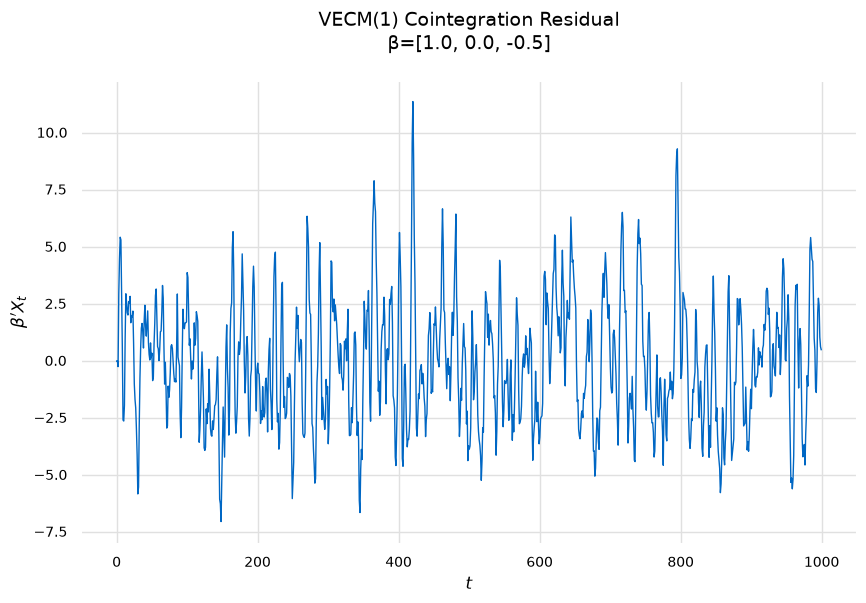

In [22]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [23]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -14.4101      │
├────────────────┼───────────────┤
│ pvalue         │   6.97986e-26 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


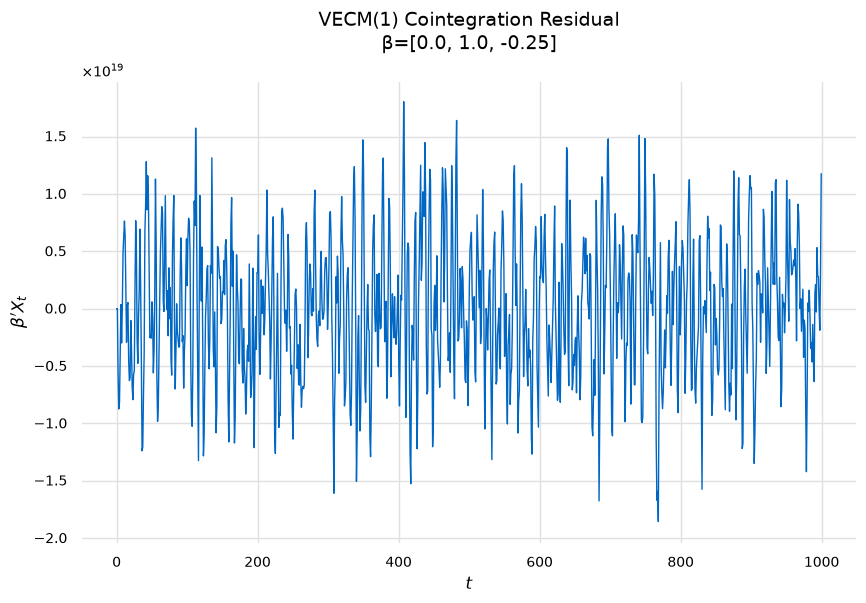

In [24]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [25]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═════════╕
│ Test Statistic │ -22.243 │
├────────────────┼─────────┤
│ pvalue         │   0     │
├────────────────┼─────────┤
│ Lags           │   1     │
├────────────────┼─────────┤
│ Number Obs     │ 998     │
╘════════════════╧═════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Cointegrating Vectors

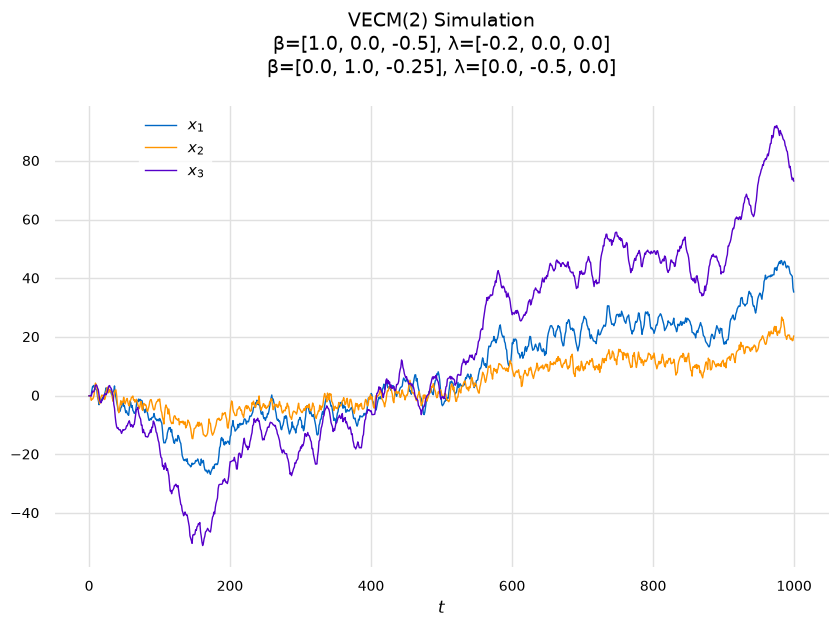

In [26]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [27]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [28]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


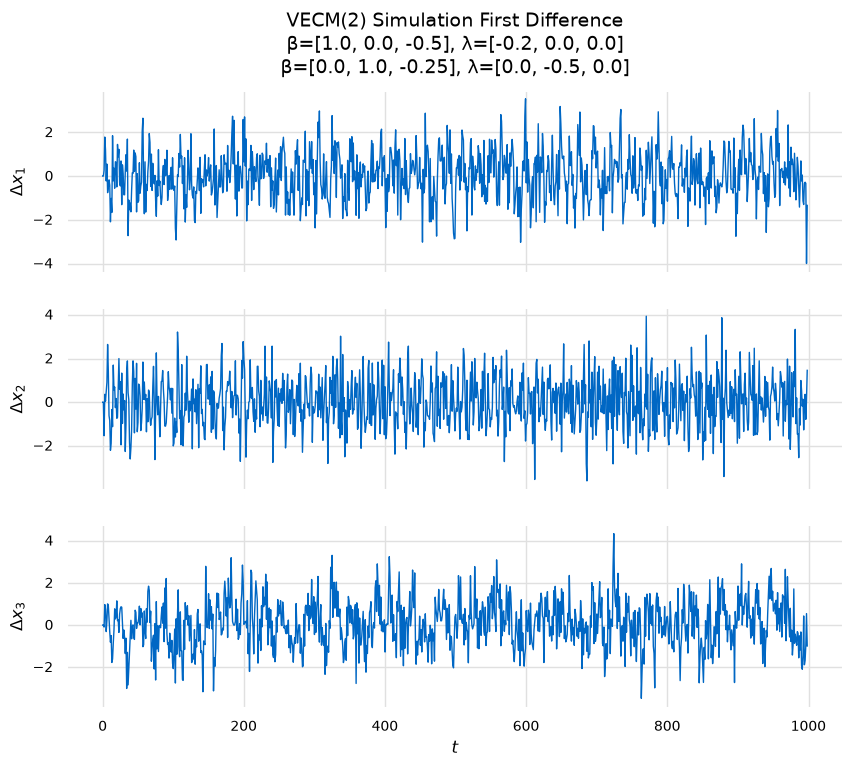

In [29]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [30]:
result, result_model = vecm.compute_lag_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3658,0.4399,1.442,0.3940
1,0.1264,0.2448,1.135,0.1714
2,-0.07694*,0.08593*,0.9260*,-0.01502*
3,-0.06500,0.1423,0.9371,0.01380
4,-0.05661,0.1951,0.9450,0.03908
5,-0.05060,0.2455,0.9507,0.06199
6,-0.03834,0.3022,0.9624,0.09113


In [31]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
   "_VAROrderTestReport__order": {
      "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
      "order": {
         "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
         "label": "$\\varepsilon_{AIC}$",
         "value": -0.0769369761923882
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
      "order": {
         "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "0719f18a-6f81-489b-8456-9678fa67b8d8",
        

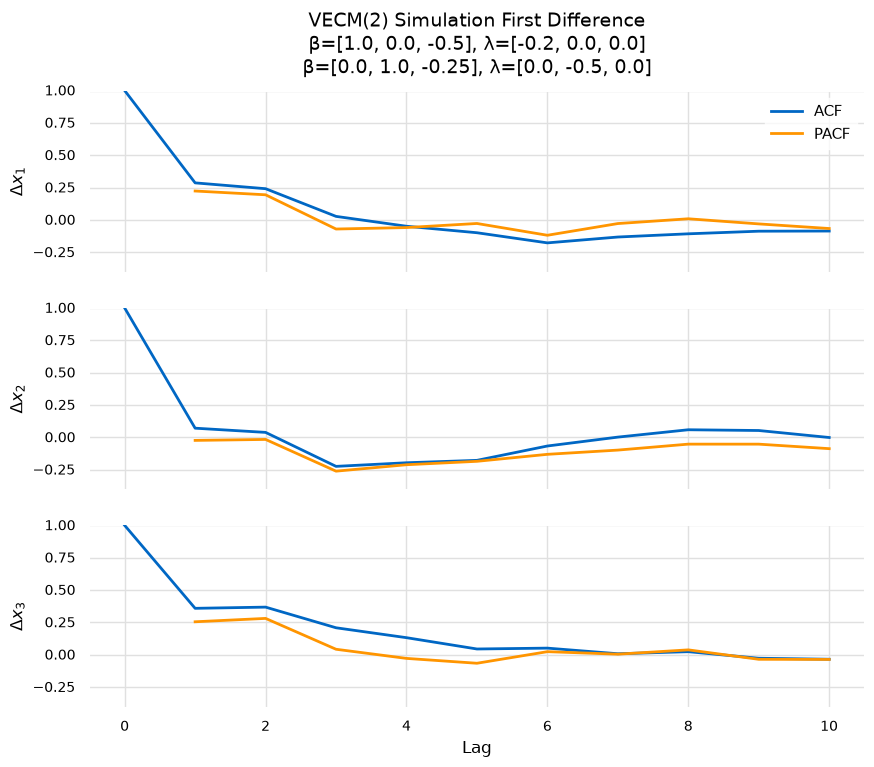

In [32]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [33]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1472.432
Date:                Sun, 30 Aug 2026   AIC                           2952.865
Time:                        17:29:36   BIC                           2972.492
Sample:                             0   HQIC                          2960.325
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0332      0.057      0.579      0.563      -0.079       0.146
ar.L1          0.2367      0.032      7.310      0.000       0.173       0.300
ar.L2          0.1769      0.033      5.436      0.000       0.113       0.241
sigma2         1.1160      0.049     22.893      0.000       1.020       1.212
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):                 0.93
Prob(Q):                              0.61   Prob(JB):                         0.63
Heteroskedasticity (H):               1.03   Skew:                            -0.05
Prob(H) (two-sided):                  0.78   Kurtosis:                         3.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1569.482
Date:                Sun, 30 Aug 2026   AIC                           3146.964
Time:                        17:29:36   BIC                           3166.591
Sample:                             0   HQIC                          3154.424
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0205      0.041      0.498      0.618      -0.060       0.101
ar.L1          0.0687      0.031      2.211      0.027       0.008       0.130
ar.L2          0.0336      0.033      1.008      0.313      -0.032       0.099
sigma2         1.3556      0.062     21.870      0.000       1.234       1.477
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 1.42
Prob(Q):                              0.80   Prob(JB):                         0.49
Heteroskedasticity (H):               1.23   Skew:                             0.09
Prob(H) (two-sided):                  0.06   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
result, _ = arima.compute_ar_estimate(dxt[2], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1431.980
Date:                Sun, 30 Aug 2026   AIC                           2871.960
Time:                        17:29:36   BIC                           2891.587
Sample:                             0   HQIC                          2879.420
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0722      0.069      1.045      0.296      -0.063       0.208
ar.L1          0.2601      0.031      8.440      0.000       0.200       0.321
ar.L2          0.2745      0.030      9.056      0.000       0.215       0.334
sigma2         1.0290      0.043     23.764      0.000       0.944       1.114
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 4.97
Prob(Q):                              0.89   Prob(JB):                         0.08
Heteroskedasticity (H):               1.11   Skew:                             0.07
Prob(H) (two-sided):                  0.34   Kurtosis:                         3.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [36]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)

In [37]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.2429,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.0104,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.1251,0.05,False,3,1
8,0.2141,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [38]:
print(result_model.to_json(pretty=True))

{
   "test_id": "23a66cc8-f276-4280-9ba2-de9df3f9c42e",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "23a66cc8-f276-4280-9ba2-de9df3f9c42e",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "23a66cc8-f276-4280-9ba2-de9df3f9c42e",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.2429,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "23a66cc8-f276-4280-9ba2-de9df3f9c42e",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [39]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

In [40]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          475.493 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          159.459 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.102 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [41]:
print(result_model.to_json(pretty=True))

{
   "test_id": "579cd383-2701-4404-90c3-e5a65a81eb2b",
   "trace_test": [
      {
         "test_id": "579cd383-2701-4404-90c3-e5a65a81eb2b",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 475.49303034148426,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ]
      },
      {
         "test_id": "579cd383-2701-4404-90c3-e5a65a81eb2b",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 159.45908884541873,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
    

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [42]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0237,0.030,0.792,0.429,-0.035,0.083
L1.y1,0.2279,0.029,7.880,0.000,0.171,0.285
L1.y2,-0.0036,0.029,-0.125,0.900,-0.060,0.053
L1.y3,0.0235,0.031,0.754,0.451,-0.038,0.085
L2.y1,0.2456,0.029,8.470,0.000,0.189,0.302
L2.y2,-0.0037,0.029,-0.127,0.899,-0.060,0.053
L2.y3,0.0109,0.032,0.345,0.730,-0.051,0.073
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0003,0.031,-0.009,0.993,-0.061,0.061
L1.y1,-0.0010,0.030,-0.032,0.975,-0.060,0.058


In [43]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.023741683365295797,
         "err": 0.029994002190988082,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "e07fab66-e05b-48be-806e-5d3cc51fbd46",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.0002692562309151628,
         "err": 0.031108264326883094,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "e07fab66-e05b-48be-806e-5d3cc51fbd46",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.03746720584473766,
         "err": 0.032187022213829485,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "e07fab66-e05b-48be-806e-5d3cc51fbd46",
         "param

In [44]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

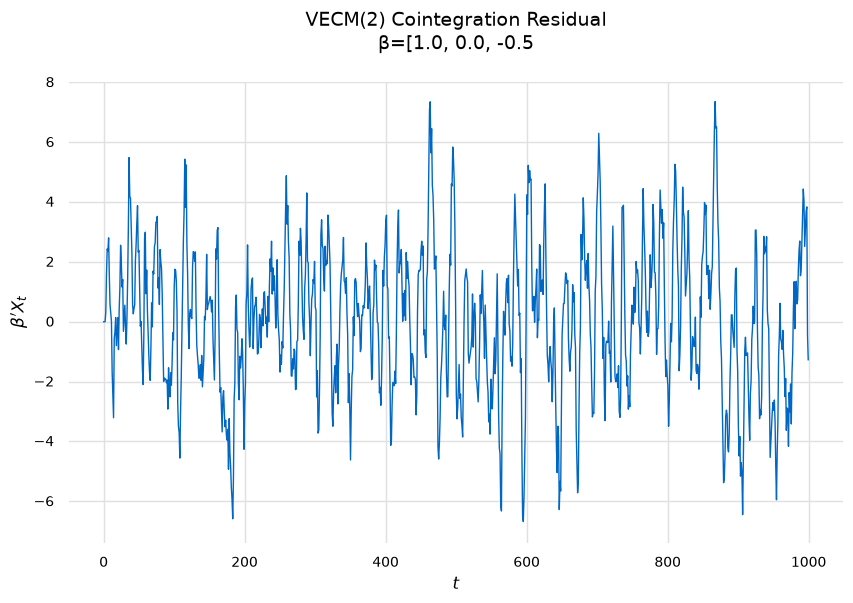

In [45]:
beta_est = result.beta
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [46]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │ -12.398      │
├────────────────┼──────────────┤
│ pvalue         │   1.2778e-22 │
├────────────────┼──────────────┤
│ Lags           │   2          │
├────────────────┼──────────────┤
│ Number Obs     │ 997          │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


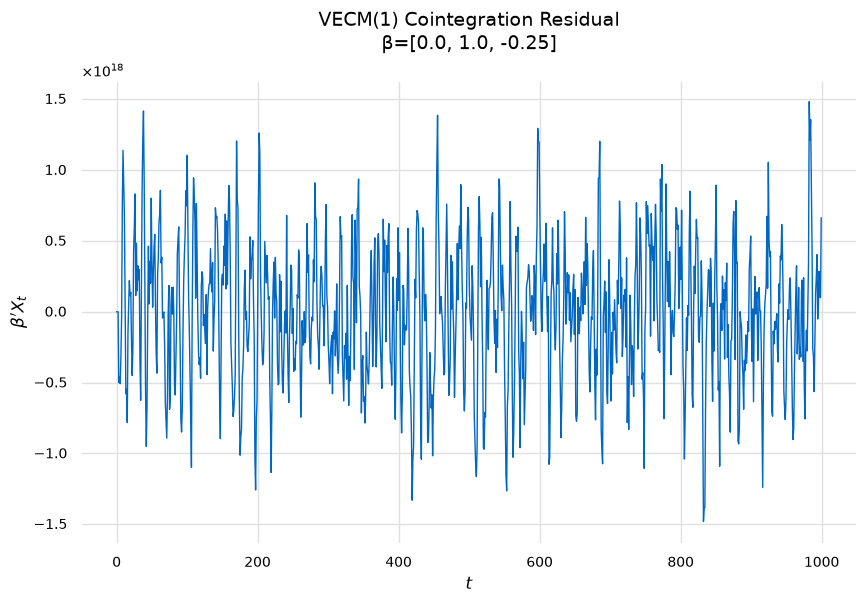

In [47]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [48]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.7705      │
├────────────────┼───────────────┤
│ pvalue         │   3.56603e-29 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(3) Two Cointegrating Vectors

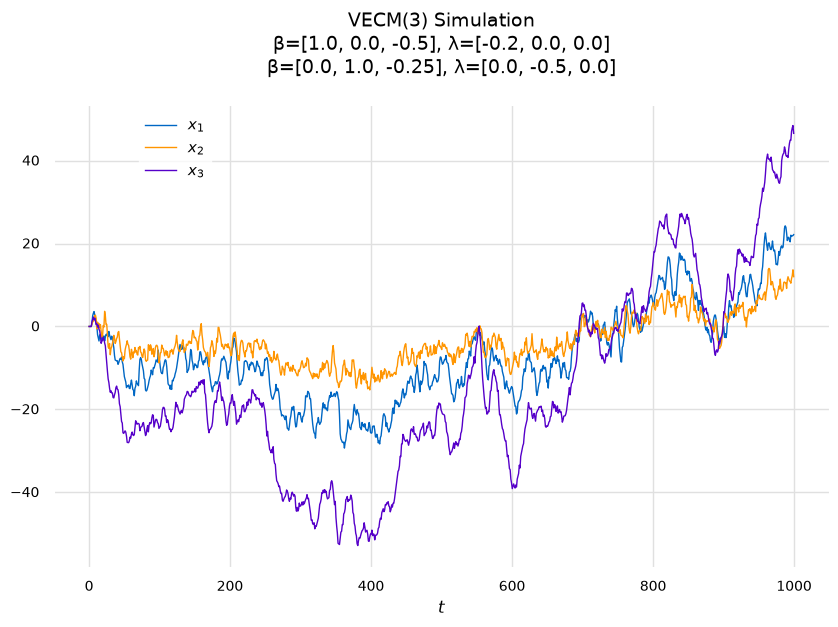

In [49]:
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(3) Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [50]:
adf_test(xt)

Not Stationary
Not Stationary
Not Stationary


In [51]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary
Stationary


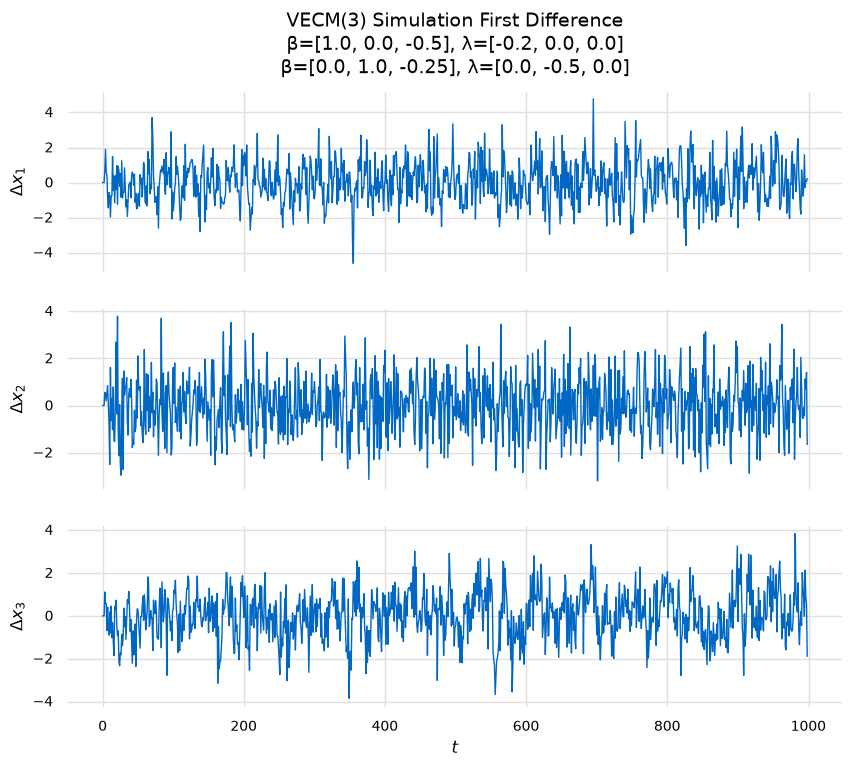

In [52]:
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [53]:
result, result_model = vecm.compute_lag_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.6783,0.7523,1.971,0.7064
1,0.4277,0.5461,1.534,0.4727
2,0.2005,0.3634*,1.222,0.2624
3,0.1738*,0.3811,1.190*,0.2526*
4,0.1888,0.4405,1.208,0.2845
5,0.1929,0.4890,1.213,0.3055
6,0.2018,0.5423,1.224,0.3313


In [54]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
   "_VAROrderTestReport__order": {
      "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
      "label": "$\\tau_{min}$",
      "value": 3
   },
   "_VAROrderTestReport__aic": {
      "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
      "order": {
         "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
         "label": "$\\tau_{AIC}$",
         "value": 3
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.1737715789127571
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
      "order": {
         "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "e39a7288-7b2c-4eeb-b70c-f29bd788f72a",
         

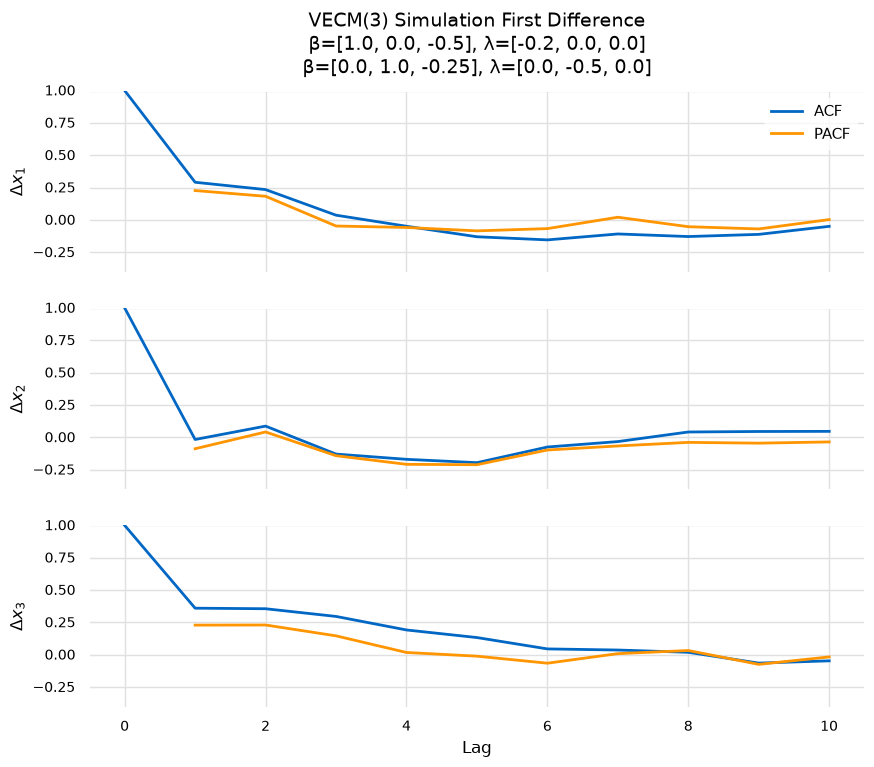

In [55]:
nlags = 10
title = f"VECM(3) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}], λ=[{λ[0,0]}, {λ[1,0]}, {λ[2,0]}]\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}], λ=[{λ[0,1]}, {λ[1,1]}, {λ[2,1]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [56]:
result, _ = arima.compute_ar_estimate(dxt[0], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1544.771
Date:                Sun, 30 Aug 2026   AIC                           3099.542
Time:                        17:29:37   BIC                           3124.076
Sample:                             0   HQIC                          3108.867
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0222      0.057      0.388      0.698      -0.090       0.135
ar.L1          0.2559      0.032      7.908      0.000       0.192       0.319
ar.L2          0.1819      0.033      5.513      0.000       0.117       0.247
ar.L3         -0.0760      0.032     -2.366      0.018      -0.139      -0.013
sigma2         1.2899      0.054     23.803      0.000       1.184       1.396
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                17.98
Prob(Q):                              0.84   Prob(JB):                         0.00
Heteroskedasticity (H):               1.49   Skew:                             0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [57]:
result, _ = arima.compute_ar_estimate(dxt[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1595.553
Date:                Sun, 30 Aug 2026   AIC                           3201.106
Time:                        17:29:37   BIC                           3225.640
Sample:                             0   HQIC                          3210.431
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0120      0.036      0.329      0.742      -0.059       0.083
ar.L1         -0.0038      0.031     -0.122      0.903      -0.065       0.057
ar.L2          0.0852      0.031      2.789      0.005       0.025       0.145
ar.L3         -0.1275      0.032     -3.972      0.000      -0.190      -0.065
sigma2         1.4281      0.066     21.608      0.000       1.299       1.558
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):                 1.74
Prob(Q):                              0.46   Prob(JB):                         0.42
Heteroskedasticity (H):               1.09   Skew:                             0.09
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [58]:
result, _ = arima.compute_ar_estimate(dxt[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1429.150
Date:                Sun, 30 Aug 2026   AIC                           2868.300
Time:                        17:29:37   BIC                           2892.834
Sample:                             0   HQIC                          2877.625
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0445      0.079      0.565      0.572      -0.110       0.199
ar.L1          0.2320      0.032      7.345      0.000       0.170       0.294
ar.L2          0.2244      0.032      7.116      0.000       0.163       0.286
ar.L3          0.1324      0.033      4.020      0.000       0.068       0.197
sigma2         1.0232      0.045     22.557      0.000       0.934       1.112
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 6.20
Prob(Q):                              0.97   Prob(JB):                         0.05
Heteroskedasticity (H):               1.12   Skew:                            -0.18
Prob(H) (two-sided):                  0.31   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [59]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=3)

In [60]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.2017,0.05,False,1,2
3,0.0000,0.05,True,1,3
4,0.0290,0.05,True,2,1
5,1.0000,0.05,False,2,2
6,0.0000,0.05,True,2,3
7,0.4674,0.05,False,3,1
8,0.1967,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [61]:
print(result_model.to_json(pretty=True))

{
   "test_id": "46bb95dd-9301-453c-929b-6e9b11fa7edc",
   "rank": 2,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "46bb95dd-9301-453c-929b-6e9b11fa7edc",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "46bb95dd-9301-453c-929b-6e9b11fa7edc",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.2017,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "46bb95dd-9301-453c-929b-6e9b11fa7edc",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [62]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 3)

In [63]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          434.268 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │          157.544 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            0.638 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [64]:
print(result_model.to_json(pretty=True))

{
   "test_id": "e36569f4-e5ed-417a-93e0-4648ca9f9c5a",
   "trace_test": [
      {
         "test_id": "e36569f4-e5ed-417a-93e0-4648ca9f9c5a",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 434.26771065562207,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ]
      },
      {
         "test_id": "e36569f4-e5ed-417a-93e0-4648ca9f9c5a",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 157.54410128075793,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
    

### VECM Parameter Estimation

```
λ = numpy.matrix([[-0.2, 0.0, 0.0],
                  [0.0, -0.5, 0.0]]).T
β = numpy.matrix([[1.0, 0.0, -0.5],
                  [0.0, 1.0, -0.25]])
a = numpy.array([[[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.25, 0.0, 0.0],
                  [0.0, 0.25, 0.0],
                  [0.0, 0.0, 0.25]],
                 [[0.1, 0.0, 0.0],
                  [0.0, 0.1, 0.0],
                  [0.0, 0.0, 0.1]]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])
```



In [65]:
result, result_model = vecm.compute_estimate(xt, maxlags=3, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0096,0.033,0.294,0.768,-0.054,0.073
L1.y1,0.2582,0.029,8.858,0.000,0.201,0.315
L1.y2,-0.0268,0.031,-0.855,0.393,-0.088,0.035
L1.y3,0.0203,0.033,0.608,0.543,-0.045,0.086
L2.y1,0.2434,0.030,8.114,0.000,0.185,0.302
L2.y2,-0.0118,0.031,-0.376,0.707,-0.073,0.050
L2.y3,-0.0423,0.034,-1.256,0.209,-0.108,0.024
L3.y1,0.0454,0.030,1.502,0.133,-0.014,0.105
L3.y2,-0.0006,0.031,-0.020,0.984,-0.062,0.061
L3.y3,0.0144,0.034,0.421,0.674,-0.053,0.082


In [66]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.009569981610641076,
         "err": 0.0325046260237649,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "2d057706-2651-40bc-8fba-a021fe4f429a",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.012353929236683828,
         "err": 0.0321321166498459,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "2d057706-2651-40bc-8fba-a021fe4f429a",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.016986241690715373,
         "err": 0.03201936820806578,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "2d057706-2651-40bc-8fba-a021fe4f429a",
         "param_type

In [67]:
beta_est = result.beta

### Verify Error Correction term Residual Stationarity

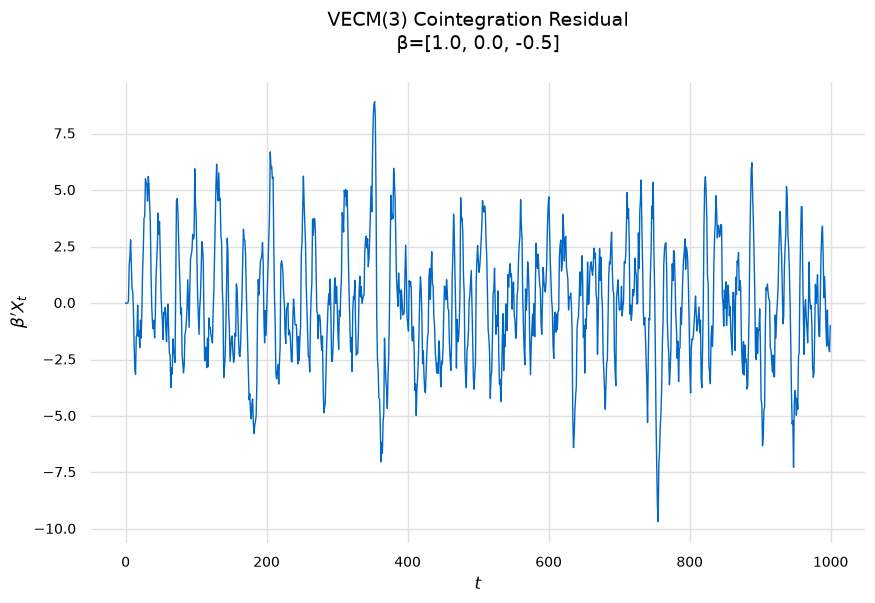

In [68]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(3) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [69]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -12.6254      │
├────────────────┼───────────────┤
│ pvalue         │   4.92807e-23 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


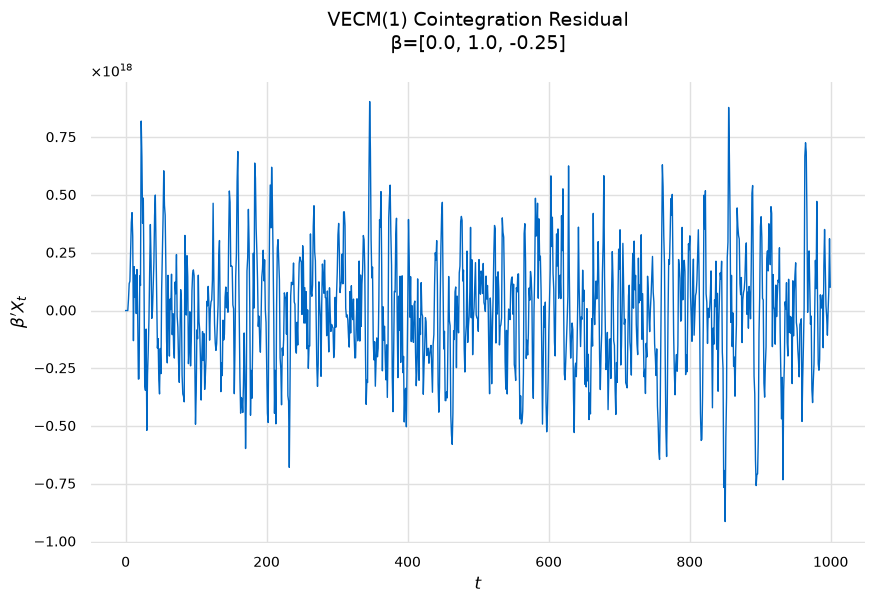

In [70]:
coint = beta_est.T[1] * xt.T / beta_est.T[1][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[1,0]}, {β[1,1]}, {β[1,2]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [71]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.3905      │
├────────────────┼───────────────┤
│ pvalue         │   9.39701e-29 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
